# TrustNote

Détection de contrefaçon de billet par analyse de données et apprentissage automatique.

Pour la présentation du contexte et du cas d'usage métier, voir le fichier `README.md` du dépôt `git`

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('./data/fake_currency_data.csv')

In [48]:
df.head(5)

,Country,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight,Length,Width,Thickness
0,USA,$100,1,25973198,Hologram,1.731759,130.243185,66.537999,0.098488
1,USA,$20,1,95903230,Security Thread,1.002179,152.596364,76.135834,0.094119
2,EU,€10,0,82937914,Hologram,2.306713,152.857126,66.772442,0.061393
3,USA,€20,1,23612989,Microprint,1.366965,143.133672,78.377052,0.053114
4,EU,€20,1,56025342,Watermark,1.796075,129.664777,75.916093,0.051438


Affichage des 5 premières lignes du dataset.

Nous avons les variables suivantes :
- country : permet de définir le pays du billet (USA, EU, UK) ;
- denomination : permet de savoir s'il s'agit d'un billet de 20€, de 5$, ... ;
- counterfeit : la variable "label", permettant de dire s'il s'agit d'un billet contrefait ou non ;
- serialnumber : numéro de série du billet
- securityFeatures : technologie de sécurité
- weight : le poids du billet
- length : la longueur du billet
- width : la largeur du billet
- thickness : l'épaisseur du billet

## Structure des données

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country           1000000 non-null  str    
 1   Denomination      1000000 non-null  str    
 2   Counterfeit       1000000 non-null  int64  
 3   SerialNumber      1000000 non-null  int64  
 4   SecurityFeatures  1000000 non-null  str    
 5   Weight            1000000 non-null  float64
 6   Length            1000000 non-null  float64
 7   Width             1000000 non-null  float64
 8   Thickness         1000000 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 68.7 MB


Nous avons 1000000 de lignes dans ce dataset.

- les variables `weight`, `length`, `width` et `thickness` sont des variables quantitative (numérique) ;
- les variables `country` et `denomination` sont des variables qualitatives (des catégories).

In [50]:
df = df.rename(columns={
    "Country": "country",
    "Denomination": "denomination",
    "Counterfeit": "counterfeit",
    "SerialNumber": "serialNumber",
    "SecurityFeatures": "security_features",
    "Weight": "weight",
    "Length": "length",
    "Width": "width",
    "Thickness": "thickness"
})

df.sample(n=5)

,country,denomination,counterfeit,serialNumber,security_features,weight,length,width,thickness
887333,UK,$5,1,79078415,Hologram,2.030250,135.844213,62.762755,0.057462
57865,USA,$100,0,37310550,Hologram,1.209889,130.113951,74.497123,0.082483
503458,EU,€5,1,61989251,Security Thread,1.376350,159.992442,73.074931,0.073558
882953,USA,€20,1,22835549,Security Thread,1.583578,156.455875,71.169308,0.065986
543469,UK,£20,1,62911435,Hologram,1.726753,121.843828,60.521259,0.088819


Renommage des variables pour avoir des minuscules.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   country            1000000 non-null  str    
 1   denomination       1000000 non-null  str    
 2   counterfeit        1000000 non-null  int64  
 3   serialNumber       1000000 non-null  int64  
 4   security_features  1000000 non-null  str    
 5   weight             1000000 non-null  float64
 6   length             1000000 non-null  float64
 7   width              1000000 non-null  float64
 8   thickness          1000000 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 68.7 MB


Nous n'avons **aucunes données manquantes.**

Regardons les répartitions de données des variables qualitatives :

<Axes: xlabel='country'>

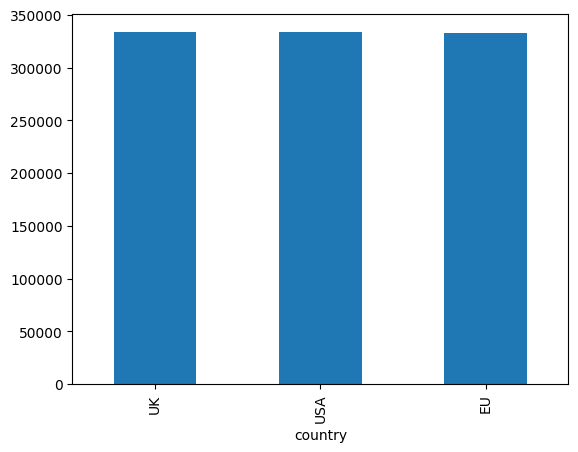

In [52]:
df['country'].value_counts().plot.bar()

<Axes: xlabel='denomination'>

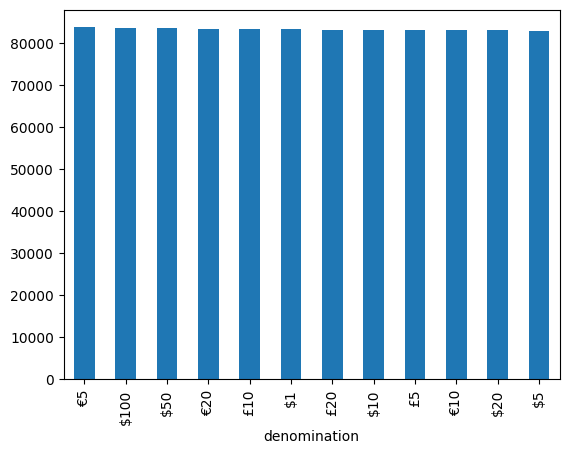

In [53]:
df['denomination'].value_counts().plot.bar()

Nous avons donc trois pays : USA, UK, EU et **douze types de billets différents**

In [54]:
cross_tab = pd.crosstab(index=df["country"], columns=df["denomination"])
cross_tab

denomination,$1,$10,$100,$20,$5,$50,£10,£20,£5,€10,€20,€5
country,,,,,,,,,,,,
EU,27749,27771,27678,27356,27431,27789,27923,27892,27707,27718,27896,28141
UK,28043,27644,28030,27810,27825,27821,27791,27694,27609,27689,27777,27878
USA,27554,27817,27904,27895,27612,27983,27718,27656,27876,27752,27821,27750


Ce tableau croisé montre que les deux variables précédentes n'ont pas de lien : nous pouvons avoir des billets de `5$` dans le country `EU`

<Axes: xlabel='security_features'>

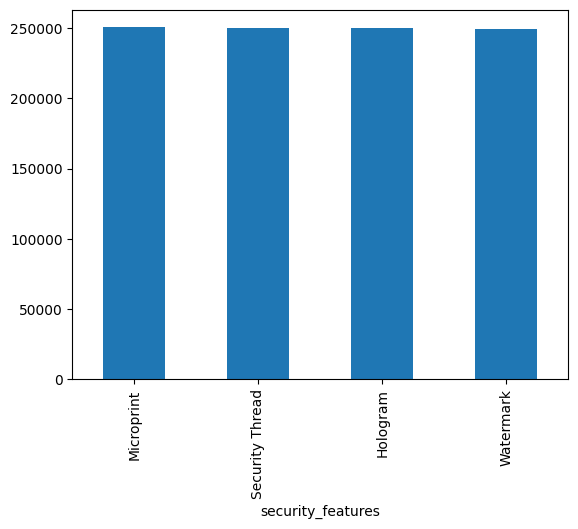

In [55]:
df['security_features'].value_counts().plot.bar()

In [56]:
df['security_features'].value_counts()

security_features
Microprint         250365
Security Thread    250208
Hologram           250046
Watermark          249381
Name: count, dtype: int64

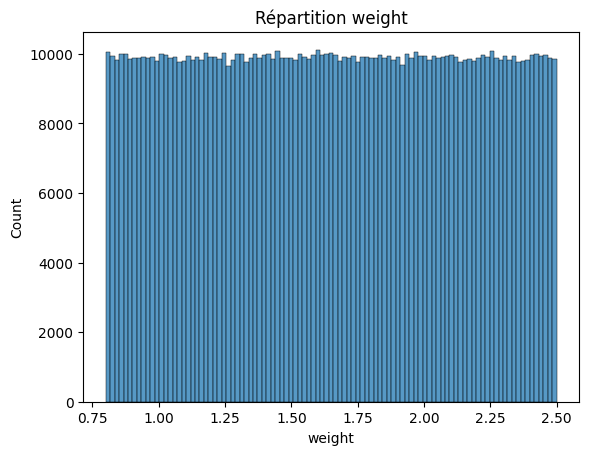

In [57]:
plt.figure()
sns.histplot(data=df["weight"])
plt.title(f"Répartition weight")
plt.show()

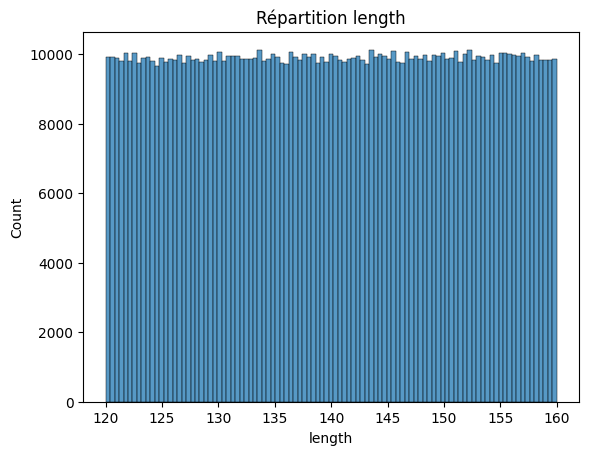

In [58]:
plt.figure()
sns.histplot(data=df["length"])
plt.title(f"Répartition length")
plt.show()

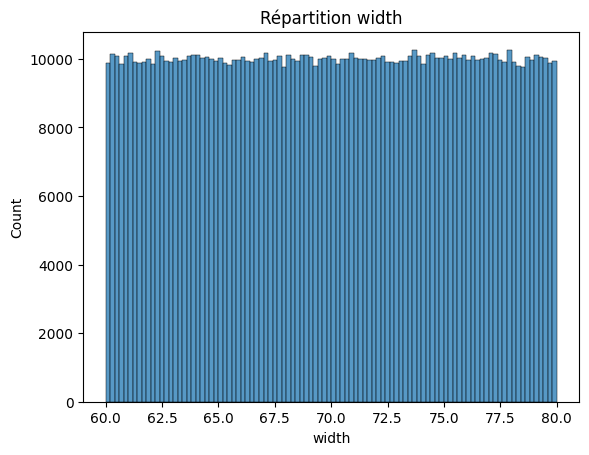

In [59]:
plt.figure()
sns.histplot(data=df["width"])
plt.title(f"Répartition width")
plt.show()

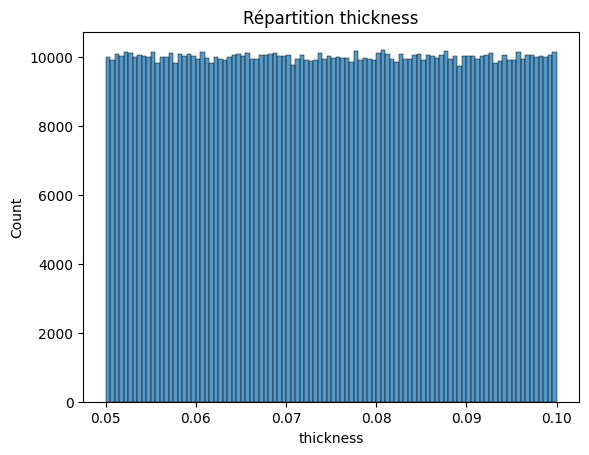

In [60]:
plt.figure()
sns.histplot(data=df["thickness"])
plt.title(f"Répartition thickness")
plt.show()

les données `weight`, `length`, `width` et `thickness` sont réparties de manière homogènes. Les distributions semblent uniformes.

## Détecter les problèmes dans les données



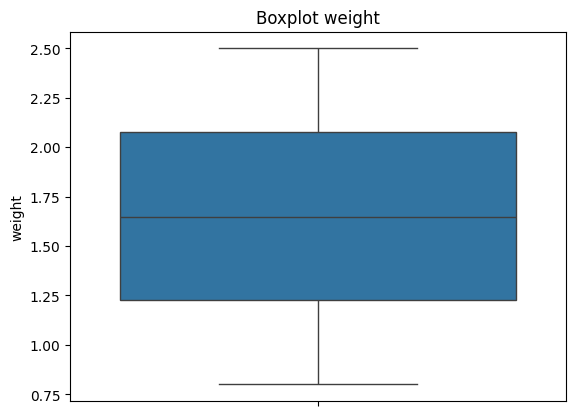

In [61]:
plt.figure()
sns.boxplot(data=df["weight"])
plt.title(f"Boxplot weight")
plt.show()

le boxplot de weight montre une distribution homogène du poids des billets, sans outliers.

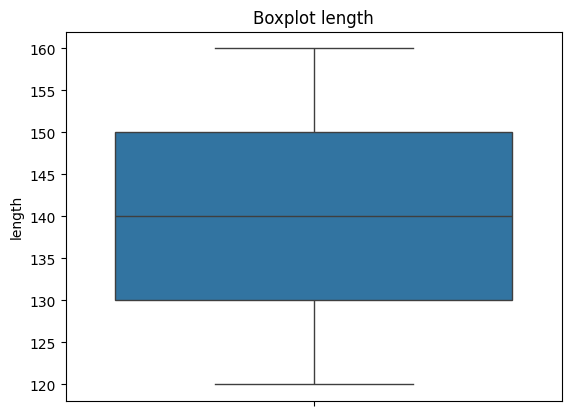

In [62]:
plt.figure()
sns.boxplot(data=df["length"])
plt.title(f"Boxplot length")
plt.show()

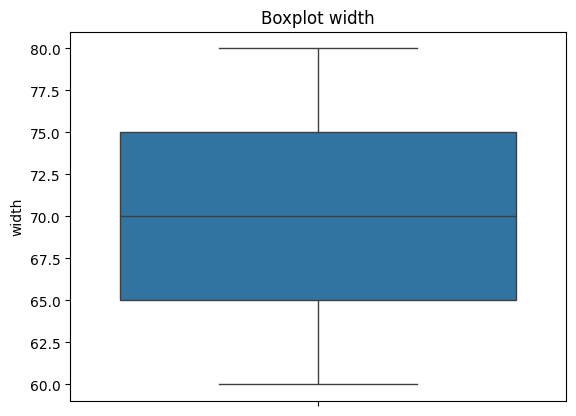

In [63]:
plt.figure()
sns.boxplot(data=df["width"])
plt.title(f"Boxplot width")
plt.show()

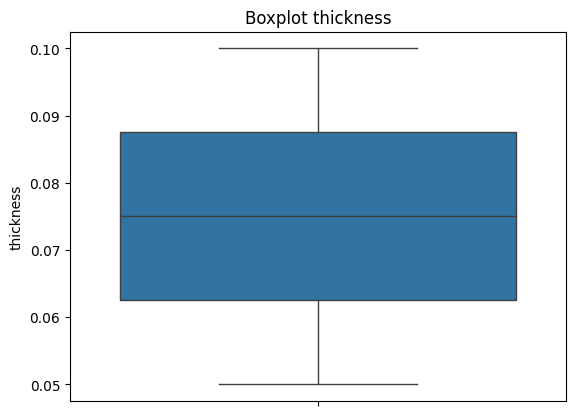

In [64]:
plt.figure()
sns.boxplot(data=df["thickness"])
plt.title(f"Boxplot thickness")
plt.show()

L'ensemble des boxplots `weigth`, `length`, `width` et `thickness` montrent une répartition des données homogène, sans outliers.

## Analyse et corrélations

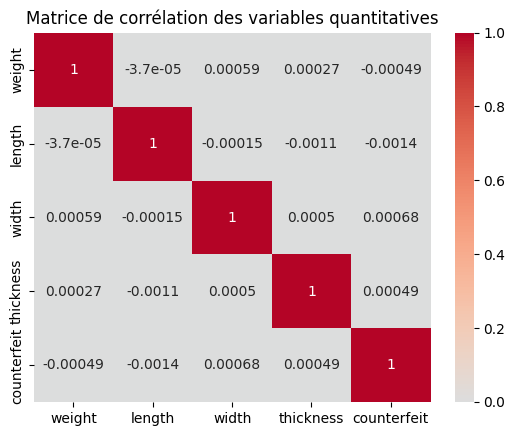

In [65]:
plt.figure()
sns.heatmap(df[["weight", "length", "width", "thickness", "counterfeit"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

il ne semble pas y'avoir de correlations simples entre les variables quantitatives.

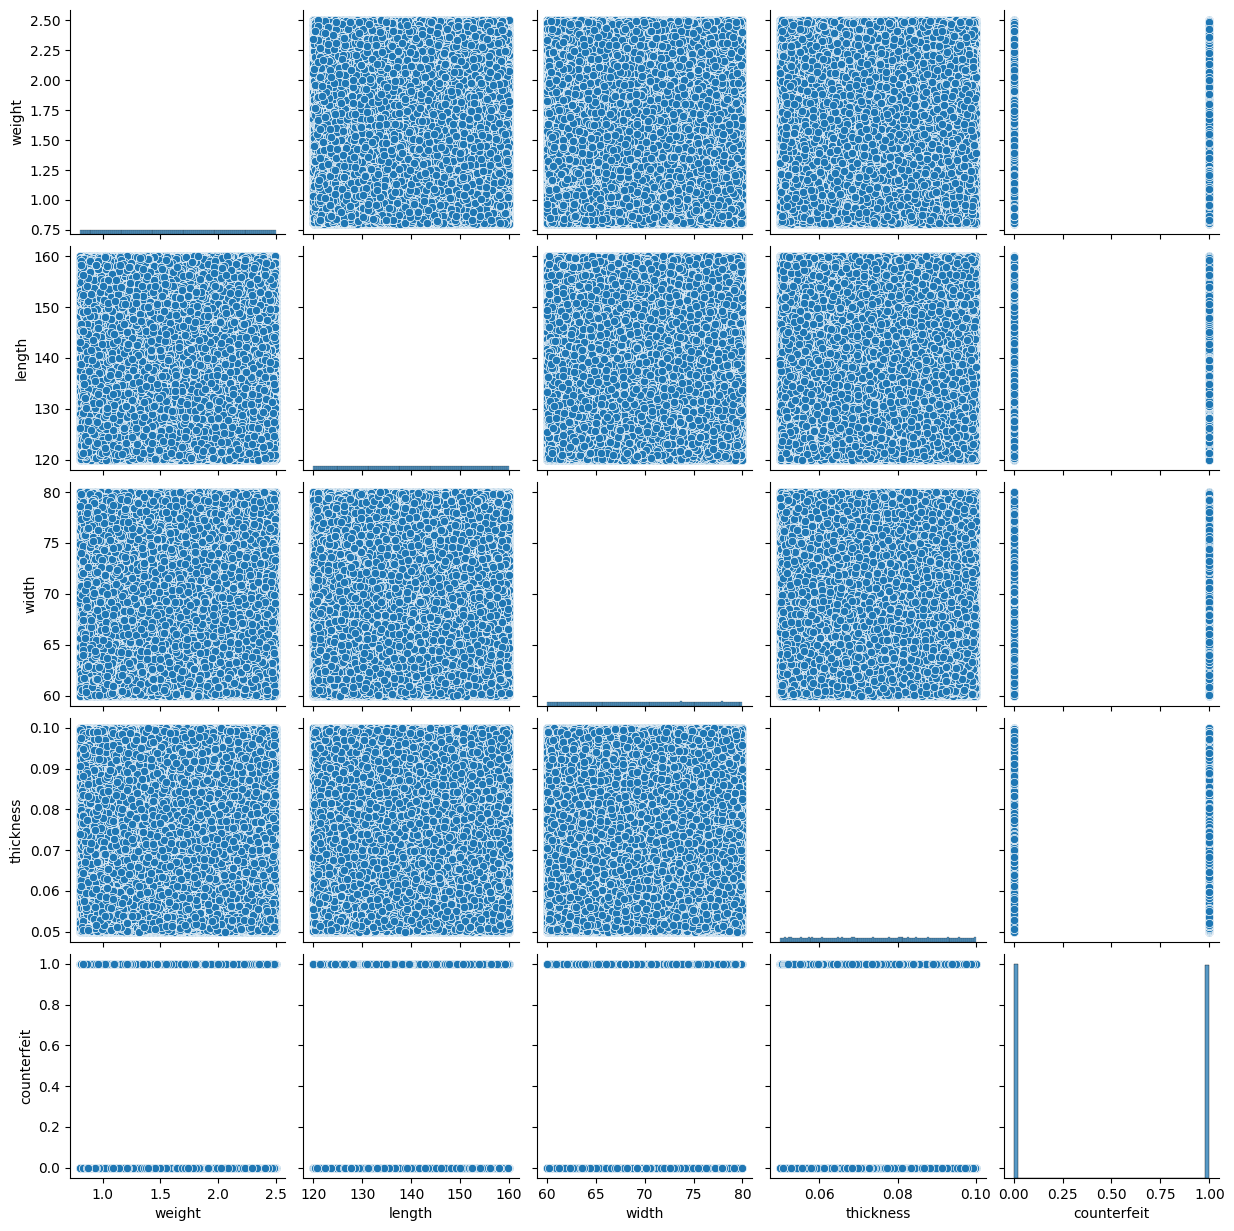

In [66]:
sns.pairplot(df[["weight", "length", "width", "thickness", "counterfeit"]])
plt.show()

Il n'y a aucun pattern pertinent dans le scatterplot, les correlations entre les variables sont nulles et nous ne parvenons pas à distinguer d'éventuels clusters simples.

## modélisation

nous allons selectionner les variables suivantes pour nos modèles :

| variable          | commentaire                                            |
| ----------------- | ------------------------------------------------------ |
| country           | Feature. Traitement en one hot encoding (3 modalités)  |
| denomination      | Feature. Traitement en one hot encoding (12 modalités) |
| counterfeit       | Label - variables à prédire                            |
| security_features | Feature. Traitement en one hot encoding (4 modalités)  |
| weight            | Feature, quantitative                                  |
| length            | Feature, quantitative                                  |
| width             | Feature, quantitative                                  |
| thickness         | Feature, quantitative                                  |

la variable `serialnumber` est exclue car elle n'apportera aucune information.

Les variables country, denomination et security_features apportent beaucoup de dimension en one-hot encoding, mais cela est necessaire en première approche.

Cela fera au total 23 dimensions, nous affinerons peut être ce choix si nous nous rendons compte qu'il y a trop de dimensions.

In [69]:
one_hot_country = pd.get_dummies(df["country"], prefix="country")
one_hot_denomonation = pd.get_dummies(df["denomination"], prefix="denomination")
one_hot_security = pd.get_dummies(df["security_features"], prefix="security")

df_one_hot = pd.concat([
    df[["weight", "length", "width", "thickness"]],
    one_hot_country,
    one_hot_denomonation,
    one_hot_security,
    df[["counterfeit"]]
], axis=1)

df_one_hot

,weight,length,width,thickness,country_EU,country_UK,country_USA,denomination_$1,denomination_$10,denomination_$100,...,denomination_£20,denomination_£5,denomination_€10,denomination_€20,denomination_€5,security_Hologram,security_Microprint,security_Security Thread,security_Watermark,counterfeit
0,1.731759,130.243185,66.537999,0.098488,False,False,True,False,False,True,...,False,False,False,False,False,True,False,False,False,1
1,1.002179,152.596364,76.135834,0.094119,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,2.306713,152.857126,66.772442,0.061393,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,0
3,1.366965,143.133672,78.377052,0.053114,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,1
4,1.796075,129.664777,75.916093,0.051438,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1.472511,134.888731,75.425943,0.093939,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,1
999996,2.355633,147.830149,65.232274,0.097358,True,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,1
999997,1.393764,150.050308,69.273269,0.068363,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,0
999998,2.026417,142.852137,77.878841,0.081160,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0


le dataframe avec les one-hot encoding.